# Part 2 - Mô hình OLS Baseline cho bài toán Data Fitting

Notebook này xây dựng toàn bộ quy trình mô hình nền tảng **Ordinary Least Squares (OLS)** cho bộ dữ liệu OASIS longitudinal. Mục tiêu dự báo là biến **MMSE**, một thang điểm thường được dùng để đánh giá trạng thái nhận thức.

Quy trình trong notebook tuân thủ các nguyên tắc quan trọng của mô hình hóa dữ liệu:

- Chỉ học các tham số tiền xử lý từ tập huấn luyện.
- Chỉ đánh giá mô hình trên tập kiểm tra được giữ riêng.
- Dùng lại hàm `ols_fit(X, y)` từ Part 1 thông qua lớp `OLSBaseline` có sẵn.
- Kiểm tra kỹ dữ liệu sau tiền xử lý để tránh lỗi lan truyền `NaN` vào mô hình.
- Báo cáo độ chính xác, suy diễn thống kê, VIF và các đồ thị chẩn đoán phần dư.

## 1. Import thư viện

Ta sử dụng `pandas` để xử lý bảng dữ liệu, `numpy` để chuyển dữ liệu sang dạng ma trận số, `matplotlib` để vẽ đồ thị, và `train_test_split` để chia dữ liệu thành tập huấn luyện và tập kiểm tra.

Hai thành phần chính của project được dùng trong notebook này là:

- `DataPipeline`: xử lý missing values, one-hot encoding và chuẩn hóa biến số.
- `OLSBaseline`: huấn luyện, đánh giá, suy diễn hệ số, tính VIF và vẽ diagnostic plots. Bên trong lớp này có gọi lại `ols_fit` từ Part 1.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Thiết lập đường dẫn project để import được các module part1/part2
# khi chạy notebook từ thư mục part2.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "part2" else NOTEBOOK_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from part2.data_pipeline import DataPipeline
from part2.model_comparison import ModelComparison, OLSBaseline, OLSWithVariables

pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Tái lập kết quả

Trong thực nghiệm thống kê và học máy, một quy trình được xem là tốt khi người khác có thể chạy lại và thu được cùng kết quả. Vì vậy ta cố định `SEED` cho NumPy, bước chia train/test và mô hình OLS baseline.

Điều này đặc biệt quan trọng vì train/test split có yếu tố ngẫu nhiên. Nếu không cố định `random_state`, mỗi lần chạy notebook có thể tạo ra tập kiểm tra khác nhau, dẫn đến metric khác nhau.

In [2]:
SEED = 42
TEST_SIZE = 0.20

np.random.seed(SEED)

print(f"Seed sử dụng: {SEED}")
print(f"Tỷ lệ test set: {TEST_SIZE:.0%}")

Seed sử dụng: 42
Tỷ lệ test set: 20%


## 3. Đọc dữ liệu

Dữ liệu được đọc từ đường dẫn yêu cầu:

`data/oasis_longitudinal.csv`

Trước khi mô hình hóa, ta quan sát kích thước dữ liệu, vài dòng đầu tiên, kiểu dữ liệu và số lượng giá trị thiếu ở từng cột. Đây là bước kiểm tra nền tảng để hiểu dữ liệu trước khi đưa vào mô hình.

In [3]:
DATA_PATH = Path("data") / "oasis_longitudinal.csv"

pipeline = DataPipeline()
df_raw = pipeline.load_dataset(str(DATA_PATH))

print(f"Kích thước dữ liệu gốc: {df_raw.shape}")
display(df_raw.head())

data_overview = pd.DataFrame({
    "dtype": df_raw.dtypes,
    "missing_count": df_raw.isna().sum(),
    "missing_rate": df_raw.isna().mean(),
})

display(data_overview)

Kích thước dữ liệu gốc: (373, 15)


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


,dtype,missing_count,missing_rate
Subject ID,object,0,0.0000
MRI ID,object,0,0.0000
Group,object,0,0.0000
Visit,int64,0,0.0000
MR Delay,int64,0,0.0000
M/F,object,0,0.0000
Hand,object,0,0.0000
Age,int64,0,0.0000
EDUC,int64,0,0.0000
SES,float64,19,0.0509


## 4. Loại bỏ các cột định danh

Hai cột `Subject ID` và `MRI ID` là các biến định danh có cardinality cao. Chúng chủ yếu dùng để nhận diện cá thể hoặc lần chụp MRI, không phải là đặc trưng lâm sàng tổng quát.

Nếu giữ các cột này trong mô hình, mô hình có thể học các mẫu giả liên quan đến mã định danh thay vì học quan hệ thực sự giữa đặc trưng và MMSE. Vì vậy ta loại bỏ chúng trước khi chia dữ liệu.

In [4]:
ID_COLUMNS = ["Subject ID", "MRI ID"]

df = df_raw.drop(columns=ID_COLUMNS).copy()
df = pipeline.remove_duplicates(df)

print(f"Kích thước sau khi bỏ ID và dòng trùng: {df.shape}")
display(df.head())

Kích thước sau khi bỏ ID và dòng trùng: (373, 13)


,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


## 5. Xử lý giá trị thiếu

Trong bài toán supervised learning, biến mục tiêu `MMSE` bắt buộc phải có giá trị. Nếu một dòng bị thiếu `MMSE`, ta không thể dùng dòng đó để huấn luyện hoặc đánh giá vì không có nhãn thật để so sánh.

Vì vậy notebook chỉ xóa các dòng thiếu target. Các giá trị thiếu ở biến đầu vào sẽ được xử lý bởi `DataPipeline` sau khi chia train/test. Cách làm này tránh rò rỉ dữ liệu vì trung bình, độ lệch chuẩn và mode chỉ được học từ tập huấn luyện.

In [5]:
TARGET = "MMSE"

rows_before = len(df)
df = df.dropna(subset=[TARGET]).reset_index(drop=True)
rows_after = len(df)

print(f"Số dòng bị xóa do thiếu {TARGET}: {rows_before - rows_after}")

missing_after_target_filter = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean(),
})

display(missing_after_target_filter)

Số dòng bị xóa do thiếu MMSE: 2


,missing_count,missing_rate
Group,0,0.0000
Visit,0,0.0000
MR Delay,0,0.0000
M/F,0,0.0000
Hand,0,0.0000
Age,0,0.0000
EDUC,0,0.0000
SES,17,0.0458
MMSE,0,0.0000
CDR,0,0.0000


## 6. Xác định biến đầu vào và biến mục tiêu

Ta đặt:

- `X`: ma trận đặc trưng, gồm tất cả các cột còn lại sau khi bỏ `MMSE`.
- `y`: vector mục tiêu, chính là điểm `MMSE`.

Về mặt lý thuyết OLS, ta giả sử quan hệ tuyến tính:

$$y = X\beta + \varepsilon$$

Trong đó $\beta$ là vector hệ số cần ước lượng và $\varepsilon$ là sai số ngẫu nhiên.

In [6]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(float)

print(f"Kích thước X: {X.shape}")
print(f"Kích thước y: {y.shape}")
display(X.head())

Kích thước X: (371, 12)
Kích thước y: (371,)


,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,CDR,eTIV,nWBV,ASF
0,Nondemented,1,0,M,R,87,14,2.0,0.0,1987,0.696,0.883
1,Nondemented,2,457,M,R,88,14,2.0,0.0,2004,0.681,0.876
2,Demented,1,0,M,R,75,12,NaN,0.5,1678,0.736,1.046
3,Demented,2,560,M,R,76,12,NaN,0.5,1738,0.713,1.010
4,Demented,3,1895,M,R,80,12,NaN,0.5,1698,0.701,1.034


## 7. Chia tập huấn luyện và tập kiểm tra

Tập huấn luyện dùng để học tham số của pipeline và mô hình. Tập kiểm tra được giữ riêng cho đến bước đánh giá cuối cùng.

Điểm quan trọng: **không fit pipeline trên toàn bộ dữ liệu trước khi chia train/test**. Nếu làm vậy, thống kê từ test set có thể đi vào quá trình chuẩn hóa hoặc imputation, gây data leakage và làm metric lạc quan hơn thực tế.

In [7]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
)

print(f"X_train_raw: {X_train_raw.shape}")
print(f"X_test_raw:  {X_test_raw.shape}")
print(f"y_train:     {y_train.shape}")
print(f"y_test:      {y_test.shape}")

X_train_raw: (296, 12)
X_test_raw:  (75, 12)
y_train:     (296,)
y_test:      (75,)


## 8. Tiền xử lý dữ liệu bằng DataPipeline

`DataPipeline` thực hiện ba nhóm thao tác chính:

1. Impute giá trị thiếu: biến số dùng mean, biến phân loại dùng mode học từ train set.
2. One-hot encode biến phân loại: chuyển các cột dạng chuỗi thành các cột nhị phân.
3. Chuẩn hóa biến số: dùng z-score để đưa biến số về cùng thang đo.

Sau khi pipeline chạy xong, notebook tiếp tục ép toàn bộ dữ liệu về dạng số, thay `inf` bằng `NaN`, rồi dùng median từ training set để điền mọi giá trị không hợp lệ còn sót lại. Đây là lớp bảo vệ bổ sung để tránh lỗi `ValueError: Input contains NaN` khi gọi `evaluate()`.

In [8]:
pipeline = DataPipeline()

# Fit pipeline chỉ trên tập huấn luyện.
X_train_processed = pipeline.fit_transform(X_train_raw, y_train)

# Transform tập kiểm tra bằng đúng tham số học được từ train set.
X_test_processed = pipeline.transform(X_test_raw)

# Ép toàn bộ dữ liệu về dạng số để phù hợp với OLS tự cài đặt.
X_train_numeric = X_train_processed.apply(pd.to_numeric, errors="coerce")
X_test_numeric = X_test_processed.apply(pd.to_numeric, errors="coerce")

# Bảo đảm train và test có cùng thứ tự cột.
feature_names = X_train_numeric.columns.tolist()
X_test_numeric = X_test_numeric.reindex(columns=feature_names)

# Tính giá trị thay thế từ train set, sau đó dùng cho cả train và test.
train_fill_values = X_train_numeric.replace([np.inf, -np.inf], np.nan).median(numeric_only=True)
train_fill_values = train_fill_values.fillna(0.0)

X_train_numeric = X_train_numeric.replace([np.inf, -np.inf], np.nan).fillna(train_fill_values)
X_test_numeric = X_test_numeric.replace([np.inf, -np.inf], np.nan).fillna(train_fill_values)

# Chuyển sang numpy arrays để truyền vào OLSBaseline.
X_train_array = X_train_numeric.to_numpy(dtype=float)
X_test_array = X_test_numeric.to_numpy(dtype=float)
y_train_array = y_train.to_numpy(dtype=float)
y_test_array = y_test.to_numpy(dtype=float)

print(f"Ma trận train sau tiền xử lý: {X_train_array.shape}")
print(f"Ma trận test sau tiền xử lý:  {X_test_array.shape}")
display(X_train_numeric.head())

Ma trận train sau tiền xử lý: (296, 15)
Ma trận test sau tiền xử lý:  (75, 15)


,Visit,MR Delay,Age,EDUC,SES,CDR,eTIV,nWBV,ASF,Group_Nondemented,Group_Demented,Group_Converted,M/F_M,M/F_F,Hand_R
192,-0.9756,-0.9502,-0.2132,-0.9184,1.3426,-0.7518,0.0991,0.2425,-0.2092,True,False,False,True,False,True
75,2.2692,2.9653,1.6278,-0.9184,1.3426,0.5495,-0.0511,-0.6352,-0.0686,False,True,False,True,False,True
84,-0.9756,-0.9502,-0.8707,0.8468,0.4631,-0.7518,0.8445,0.9607,-0.8903,True,False,False,False,True,True
359,-0.9756,-0.9502,-1.3967,-0.5653,-0.4165,-0.7518,0.0067,0.4287,-0.1204,True,False,False,False,True,True
16,0.1060,-0.0510,-1.0022,-0.9184,-0.4165,0.5495,-0.0800,1.6256,-0.0315,False,True,False,True,False,True


## 9. Kiểm tra sanity trước khi huấn luyện

OLS yêu cầu dữ liệu đầu vào là ma trận số hữu hạn. Nếu trong `X_test` hoặc `y_test` còn `NaN`, các hàm metric của scikit-learn sẽ báo lỗi trong lúc đánh giá.

Do đó ta kiểm tra rõ ràng:

- Số lượng `NaN`.
- Số lượng `inf` hoặc `-inf`.
- Kích thước train/test có khớp với target hay không.
- Số cột train và test có giống nhau hay không.

In [9]:
def summarize_array(name, values):
    """Tóm tắt nhanh trạng thái hữu hạn của một numpy array."""
    values = np.asarray(values, dtype=float)
    return {
        "name": name,
        "shape": values.shape,
        "nan_count": int(np.isnan(values).sum()),
        "inf_count": int(np.isinf(values).sum()),
        "all_finite": bool(np.isfinite(values).all()),
    }

sanity_table = pd.DataFrame([
    summarize_array("X_train_array", X_train_array),
    summarize_array("X_test_array", X_test_array),
    summarize_array("y_train_array", y_train_array),
    summarize_array("y_test_array", y_test_array),
])

display(sanity_table)

assert X_train_array.shape[0] == y_train_array.shape[0]
assert X_test_array.shape[0] == y_test_array.shape[0]
assert X_train_array.shape[1] == X_test_array.shape[1]
assert np.isfinite(X_train_array).all()
assert np.isfinite(X_test_array).all()
assert np.isfinite(y_train_array).all()
assert np.isfinite(y_test_array).all()

print("Tất cả sanity checks đều đạt.")

,name,shape,nan_count,inf_count,all_finite
0,X_train_array,"(296, 15)",0,0,True
1,X_test_array,"(75, 15)",0,0,True
2,y_train_array,"(296,)",0,0,True
3,y_test_array,"(75,)",0,0,True


Tất cả sanity checks đều đạt.


## 10. Huấn luyện mô hình OLS Baseline

OLS ước lượng hệ số bằng cách tối thiểu hóa tổng bình phương phần dư:

$$\min_{\beta} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Nghiệm ma trận quen thuộc là:

$$\hat{\beta} = (X^TX)^{-1}X^Ty$$

Trong project này, hàm `ols_fit(X, y)` ở Part 1 tự thêm intercept vào ma trận thiết kế. Vì vậy ta truyền vào ma trận đặc trưng **không tự thêm cột intercept**. Lớp `OLSBaseline` gọi lại `ols_fit`, lưu hệ số, phương sai phần dư, fitted values và residuals.

In [10]:
ols_model = OLSBaseline(random_state=SEED)
ols_model.fit(X_train_array, y_train_array)

print("Huấn luyện OLS baseline thành công.")
print(f"Số hệ số bao gồm intercept: {len(ols_model.beta_hat)}")
print(f"Ước lượng phương sai phần dư sigma^2: {ols_model.sigma2_hat:.4f}")

Huấn luyện OLS baseline thành công.
Số hệ số bao gồm intercept: 16
Ước lượng phương sai phần dư sigma^2: 6.2432


## 11. Đánh giá mô hình trên held-out test set

Mô hình được đánh giá nghiêm ngặt trên tập kiểm tra chưa từng dùng để fit pipeline hoặc fit OLS. Ba metric được báo cáo là:

- **MAE**: sai số tuyệt đối trung bình, dễ diễn giải theo đơn vị MMSE.
- **RMSE**: căn bậc hai của sai số bình phương trung bình, phạt nặng các sai số lớn.
- **R2_test**: tỷ lệ phương sai của target trên test set được giải thích bởi mô hình.

Vì đã kiểm tra `X_test_array` không chứa `NaN`, bước này sẽ không còn gặp lỗi `ValueError: Input contains NaN`.

In [11]:
metrics = ols_model.evaluate(X_test_array, y_test_array)

metrics_table = pd.DataFrame([metrics], index=["OLS Baseline"])
display(metrics_table)

,MAE,RMSE,R2_test
OLS Baseline,1.7376,2.8904,0.4551


## 12. Suy diễn thống kê cho hệ số

Sau khi ước lượng hệ số, ta không chỉ quan tâm mô hình dự báo tốt hay không, mà còn muốn hiểu từng biến có quan hệ như thế nào với `MMSE`.

Bảng suy diễn hệ số gồm:

- `coefficient`: hệ số ước lượng.
- `std_error`: sai số chuẩn của hệ số.
- `t_stat`: thống kê t dùng để kiểm định hệ số khác 0.
- `p_value`: mức ý nghĩa thống kê.
- `ci_lower`, `ci_upper`: khoảng tin cậy 95%.

Nếu `p_value` nhỏ, có bằng chứng thống kê rằng hệ số tương ứng khác 0 trong mô hình tuyến tính đang xét. Tuy nhiên cần diễn giải cẩn thận vì đa cộng tuyến và quan hệ phi tuyến có thể ảnh hưởng đến ý nghĩa của từng hệ số.

In [12]:
inference_table = ols_model.run_inference(feature_names)

display(inference_table)

,feature,coefficient,std_error,t_stat,p_value,ci_lower,ci_upper
0,Intercept,9.7470,0.0701,139.0666,2.0270e-260,9.6090,9.8849
1,Visit,-0.4977,0.4060,-1.2259,2.2127e-01,-1.2968,0.3015
2,MR Delay,0.4642,0.4104,1.1310,2.5902e-01,-0.3437,1.2722
3,Age,0.4584,0.1851,2.4762,1.3871e-02,0.0940,0.8228
4,EDUC,0.1902,0.2226,0.8546,3.9349e-01,-0.2479,0.6284
5,SES,-0.3710,0.2261,-1.6408,1.0197e-01,-0.8161,0.0741
6,CDR,-2.1497,0.2790,-7.7043,2.2897e-13,-2.6989,-1.6004
7,eTIV,-0.0071,1.0161,-0.0070,9.9445e-01,-2.0073,1.9931
8,nWBV,0.8225,0.1979,4.1562,4.3043e-05,0.4329,1.2120
9,ASF,-0.0037,1.0031,-0.0037,9.9709e-01,-1.9783,1.9710


## 13. Kiểm tra đa cộng tuyến bằng VIF

Đa cộng tuyến xảy ra khi một biến đầu vào có thể được giải thích khá tốt bởi các biến đầu vào khác. Khi đa cộng tuyến cao, hệ số OLS có thể trở nên kém ổn định: sai số chuẩn lớn hơn, dấu hệ số dễ thay đổi và việc diễn giải từng biến trở nên khó hơn.

Variance Inflation Factor của biến $X_j$ được hiểu là:

$$VIF_j = \frac{1}{1 - R_j^2}$$

Trong đó $R_j^2$ là R-squared khi hồi quy $X_j$ theo các biến còn lại. Quy ước thường dùng: **VIF > 10** là dấu hiệu đa cộng tuyến cao.

In [13]:
vif_table = ols_model.compute_vif(X_train_array, feature_names)
vif_table = vif_table.sort_values("VIF", ascending=False, na_position="last").reset_index(drop=True)

display(vif_table)

high_vif_table = vif_table[vif_table["High Multicollinearity"]]
print(f"Số biến có VIF > 10: {len(high_vif_table)}")

if len(high_vif_table) > 0:
    display(high_vif_table)

,feature,VIF,High Multicollinearity
0,Group_Nondemented,inf,True
1,Group_Demented,inf,True
2,Group_Converted,inf,True
3,M/F_M,inf,True
4,M/F_F,inf,True
5,Hand_R,inf,True
6,eTIV,48.7859,True
7,ASF,47.5478,True
8,MR Delay,7.9603,False
9,Visit,7.7870,False


Số biến có VIF > 10: 8


,feature,VIF,High Multicollinearity
0,Group_Nondemented,inf,True
1,Group_Demented,inf,True
2,Group_Converted,inf,True
3,M/F_M,inf,True
4,M/F_F,inf,True
5,Hand_R,inf,True
6,eTIV,48.7859,True
7,ASF,47.5478,True


## 14. OLS với lựa chọn biến

Để so sánh công bằng hơn với Ridge, Lasso, ta thêm một baseline OLS có lựa chọn biến trước khi fit. Notebook dùng chiến lược VIF: lặp lại việc loại biến có VIF lớn nhất cho đến khi mọi biến còn lại có `VIF <= 10`.

Các biến bị loại không phải vì không liên quan đến `MMSE`; chúng bị loại vì có đa cộng tuyến cao với các biến khác, làm hệ số OLS kém ổn định hơn. Việc fit OLS vẫn dùng `OLSBaseline`, nên toàn bộ phần tính OLS tiếp tục tái sử dụng `ols_fit` từ Part 1.

In [14]:
comparison = ModelComparison()

comparison_table, selection_info = comparison.compare_metrics_with_variable_selection(
    X_train_numeric,
    y_train,
    X_test_numeric,
    y_test,
    vif_threshold=10.0,
)

X_train_selected = selection_info["X_train_selected"]
X_test_selected = selection_info["X_test_selected"]
feature_names_selected = selection_info["feature_names_selected"]
selection_vif_table = selection_info["vif_table"]
removed_features = selection_info["removed_features"]

print(f"Số biến ban đầu: {len(feature_names)}")
print(f"Số biến sau khi chọn: {len(feature_names_selected)}")
print("Các biến được giữ lại:")
display(pd.Series(feature_names_selected, name="selected_feature").to_frame())

print("Bảng VIF sau khi chọn biến, kèm các biến bị loại:")
display(selection_vif_table)

if removed_features:
    print("Các biến bị loại do VIF > 10:")
    display(pd.Series(removed_features, name="removed_feature").to_frame())
else:
    print("Không có biến nào bị loại theo ngưỡng VIF > 10.")

display(comparison_table)


Số biến ban đầu: 15
Số biến sau khi chọn: 12
Các biến được giữ lại:


,selected_feature
0,Visit
1,MR Delay
2,Age
3,EDUC
4,SES
5,CDR
6,nWBV
7,ASF
8,Group_Demented
9,Group_Converted


Bảng VIF sau khi chọn biến, kèm các biến bị loại:


,feature,VIF,High Multicollinearity,removed
0,MR Delay,7.9476,False,False
1,Visit,7.7684,False,False
2,Hand_R,7.6038,False,False
3,Group_Demented,4.2684,False,False
4,CDR,3.6747,False,False
5,EDUC,2.3345,False,False
6,SES,2.3079,False,False
7,nWBV,1.8448,False,False
8,M/F_F,1.6600,False,False
9,ASF,1.6505,False,False


Các biến bị loại do VIF > 10:


,removed_feature
0,Group_Nondemented
1,M/F_M
2,eTIV


,MAE,RMSE,R2_test
OLS,1.7377,2.8905,0.4551
Ridge (λ=23.1013),1.6900,2.9329,0.4390
Lasso (λ=0.1000),1.6917,3.0108,0.4088


## 15. Ridge và Lasso với Cross-Validation chọn λ

Trong OLS thuần, không có siêu tham số cần điều chỉnh. Tuy nhiên Ridge và Lasso đều có **tham số điều chuẩn λ (alpha)** kiểm soát mức độ phạt:

- **Ridge** : $\hat{\beta}_{ridge} = \arg\min_{\beta} \|y - X\beta\|_2^2 + \lambda\|\beta\|_2^2$
- **Lasso** : $\hat{\beta}_{lasso} = \arg\min_{\beta} \|y - X\beta\|_2^2 + \lambda\|\beta\|_1$

λ quá nhỏ → gần như OLS, dễ overfit. λ quá lớn → phạt quá mạnh, underfit. Ta dùng **5-Fold Cross-Validation** để chọn λ tối ưu:

1. Chia tập huấn luyện thành 5 phần bằng nhau.
2. Mỗi lần dùng 1 phần để validate, 4 phần còn lại để train.
3. Tính MSE trung bình trên 5 lần — lặp lại cho từng giá trị λ trong lưới ứng viên.
4. Chọn λ có **CV MSE thấp nhất**.

In [15]:
# 1. Khởi tạo lưới lambda ứng viên và chạy Cross-Validation
comparison = ModelComparison()
alphas = np.logspace(-3, 3, 100)

ridge_best_alpha, ridge_cv_mse = comparison.cv_select_alpha(
    X_train_numeric, y_train, model_type="ridge", alphas=alphas, k=5
)
lasso_best_alpha, lasso_cv_mse = comparison.cv_select_alpha(
    X_train_numeric, y_train, model_type="lasso", alphas=alphas, k=5
)

print(f"Ridge - lambda tối ưu : {ridge_best_alpha:.6f}  |  CV MSE tốt nhất: {ridge_cv_mse.min():.4f}")
print(f"Lasso - lambda tối ưu : {lasso_best_alpha:.6f}  |  CV MSE tốt nhất: {lasso_cv_mse.min():.4f}")

Ridge - lambda tối ưu : 20.092330  |  CV MSE tốt nhất: 6.3996
Lasso - lambda tối ưu : 0.100000  |  CV MSE tốt nhất: 6.3617


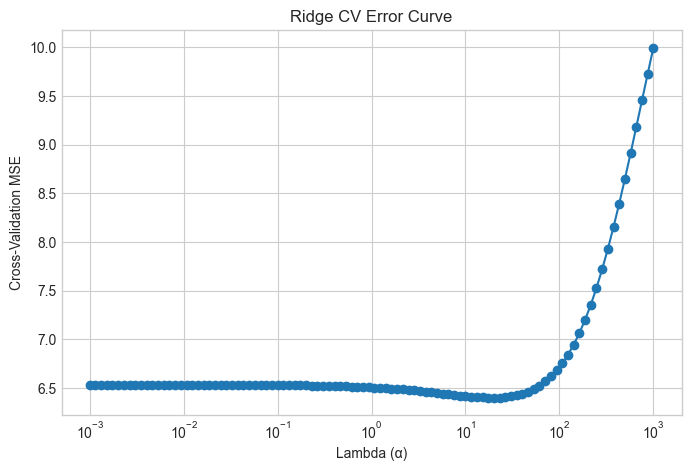

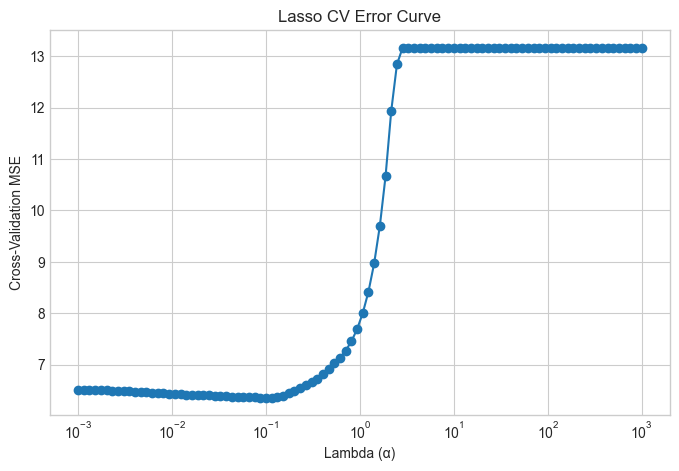

In [16]:
# 2. Vẽ CV error curve theo lambda
comparison.plot_cv_error_curve(alphas, ridge_cv_mse, model_name="Ridge")
comparison.plot_cv_error_curve(alphas, lasso_cv_mse, model_name="Lasso")

In [17]:
# 3. Fit final model với lambda tối ưu và đánh giá trên tập kiểm tra
ridge_model = comparison.train_ridge_regression(
    X_train_numeric, y_train, alpha=ridge_best_alpha
)
lasso_model = comparison.train_lasso_regression(
    X_train_numeric, y_train, alpha=lasso_best_alpha
)

ridge_metrics = comparison.evaluate_model(ridge_model, X_test_numeric, y_test)
lasso_metrics = comparison.evaluate_model(lasso_model, X_test_numeric, y_test)

print(f"--- Ridge (λ = {ridge_best_alpha:.4f}) ---")
print(f"MAE:     {ridge_metrics['MAE']:.4f}")
print(f"RMSE:    {ridge_metrics['RMSE']:.4f}")
print(f"R²_test: {ridge_metrics['R2_test']:.4f}")
print()
print(f"--- Lasso (λ = {lasso_best_alpha:.4f}) ---")
print(f"MAE:     {lasso_metrics['MAE']:.4f}")
print(f"RMSE:    {lasso_metrics['RMSE']:.4f}")
print(f"R²_test: {lasso_metrics['R2_test']:.4f}")

--- Ridge (λ = 20.0923) ---
MAE:     1.6913
RMSE:    2.9277
R²_test: 0.4410

--- Lasso (λ = 0.1000) ---
MAE:     1.6917
RMSE:    3.0108
R²_test: 0.4088


## 16. Chẩn đoán phần dư

Phần dư là sai khác giữa giá trị thật và giá trị mô hình dự báo:

$$e_i = y_i - \hat{y}_i$$

Bốn đồ thị chẩn đoán giúp kiểm tra các giả định và điểm bất thường của OLS:

1. **Residuals vs Fitted**: kiểm tra tính tuyến tính và pattern còn sót lại trong phần dư.
2. **Q-Q Plot**: kiểm tra phần dư có gần phân phối chuẩn hay không.
3. **Scale-Location**: kiểm tra phương sai phần dư có tương đối ổn định hay không.
4. **Cook's Distance**: phát hiện quan sát có ảnh hưởng mạnh đến mô hình.

Các đồ thị này được tạo từ phần dư trên tập huấn luyện vì chúng phản ánh hành vi của mô hình đã fit.

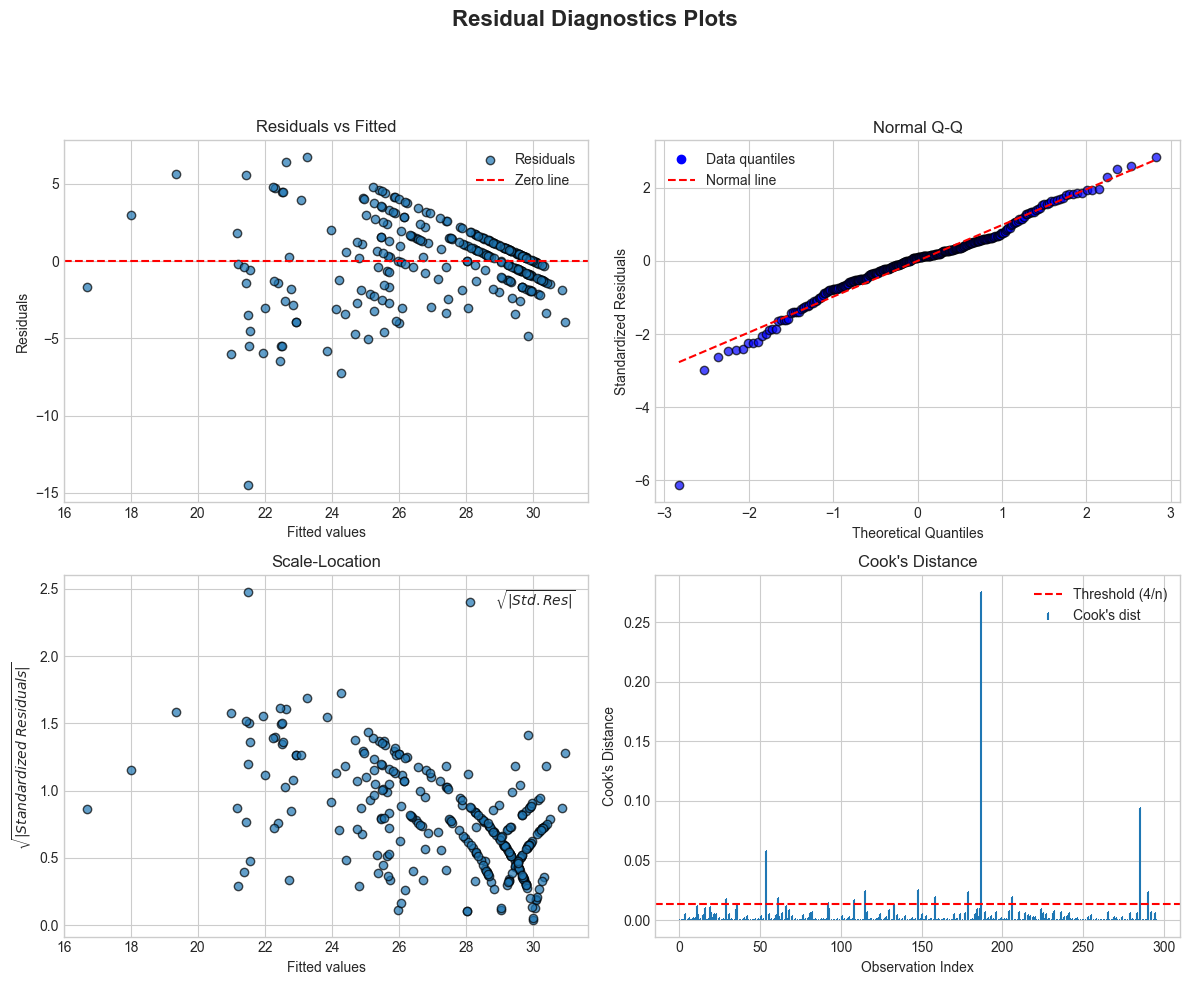

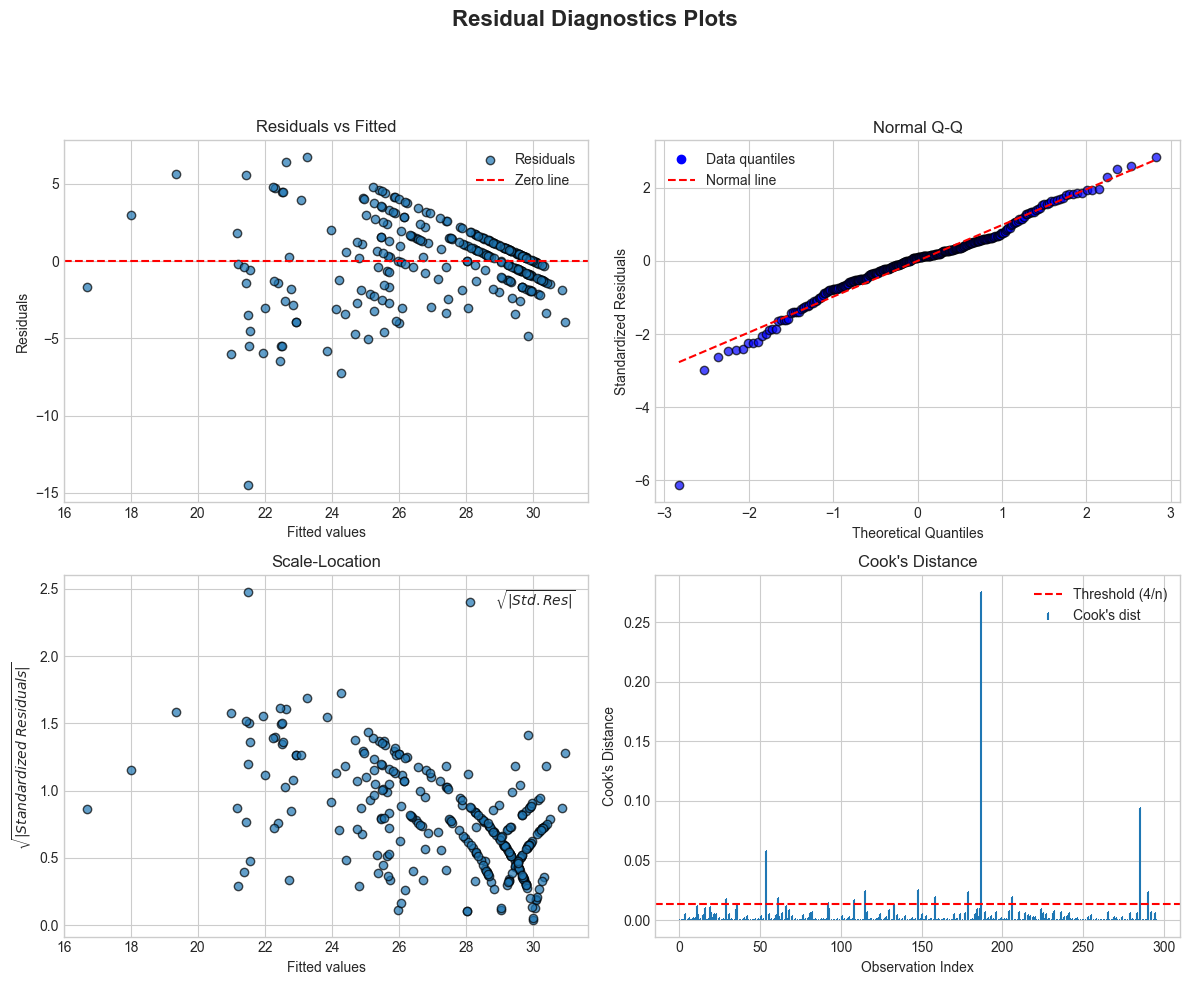

In [18]:
ols_model.diagnostic_plots()

## 17. Đánh giá mô hình trên tập kiểm tra

Trong bước này, chúng ta huấn luyện và so sánh nhiều mô hình hồi quy khác nhau (OLS, Ridge và Lasso) trên tập đặc trưng đã được chọn lọc bằng phương pháp VIF.

Tất cả các mô hình được đánh giá trên tập kiểm tra (test set) bằng ba chỉ số chính:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² (Coefficient of Determination)

Mục tiêu của bước này là đánh giá hiệu quả dự đoán của từng mô hình trong điều kiện đã kiểm soát đa cộng tuyến giữa các biến đầu vào.

In [19]:
comparison_table = comparison.compare_metrics(
    X_train_selected,
    y_train,
    X_test_selected,
    y_test
)

display(comparison_table)

,MAE,RMSE,R2_test
OLS,1.7377,2.8905,0.4551
Ridge (λ=23.1013),1.6900,2.9329,0.4390
Lasso (λ=0.1000),1.6917,3.0108,0.4088


## Tổng Hợp So Sánh 4 Mô Hình

Bảng dưới tổng hợp kết quả của toàn bộ 4 mô hình trên cùng tập kiểm tra,
giúp so sánh trực tiếp hiệu quả giữa OLS thuần, OLS có lọc biến VIF,
Ridge và Lasso.

- **OLS Baseline**: hồi quy tuyến tính với toàn bộ đặc trưng, không regularization.
- **OLS + VIF Selection**: loại bỏ biến có VIF > 10 trước khi fit, giảm đa cộng tuyến.
- **Ridge**: phạt L2, co nhỏ hệ số nhưng không đưa về 0, λ chọn qua 5-fold CV.
- **Lasso**: phạt L1, tự động loại biến không quan trọng (hệ số = 0), λ chọn qua 5-fold CV.

In [20]:
# Tổng hợp tất cả 4 mô hình vào một bảng so sánh duy nhất
ols_metrics = ols_model.evaluate(X_test_array, y_test_array)

ols_vif_model = OLSWithVariables(vif_threshold=10.0)
ols_vif_model.fit(X_train_numeric, y_train)
ols_vif_metrics = ols_vif_model.evaluate(X_test_numeric, y_test)

ridge_metrics = comparison.evaluate_model(ridge_model, X_test_numeric, y_test)
lasso_metrics = comparison.evaluate_model(lasso_model, X_test_numeric, y_test)

summary_df = pd.DataFrame({
    "OLS Baseline":              ols_metrics,
    f"OLS + VIF Selection":      ols_vif_metrics,
    f"Ridge (λ={ridge_best_alpha:.4f})": ridge_metrics,
    f"Lasso (λ={lasso_best_alpha:.4f})": lasso_metrics,
}).T

display(summary_df)
print(comparison.generate_summary(summary_df))

,MAE,RMSE,R2_test
OLS Baseline,1.7376,2.8904,0.4551
OLS + VIF Selection,1.7377,2.8905,0.4551
Ridge (λ=20.0923),1.6913,2.9277,0.4410
Lasso (λ=0.1000),1.6917,3.0108,0.4088


         MODEL COMPARISON SUMMARY
  Best RMSE : OLS Baseline (2.8904)
  Best R²   : OLS Baseline (0.4551)
  Best MAE  : Ridge (λ=20.0923) (1.6913)


## 18. Kết luận

Notebook này đã hoàn thành quy trình OLS baseline cho Part 2:

- Đọc đúng bộ dữ liệu OASIS từ `data/oasis_longitudinal.csv`.
- Loại bỏ các cột ID có cardinality cao.
- Xóa an toàn các dòng thiếu target `MMSE`.
- Chia train/test trước khi fit pipeline để tránh data leakage.
- Dùng `DataPipeline.fit_transform` trên training set và `DataPipeline.transform` trên test set.
- Chuyển dữ liệu sau tiền xử lý thành numpy arrays dạng số.
- Kiểm tra và ngăn `NaN` hoặc `inf` lan truyền vào mô hình.
- Huấn luyện OLS baseline bằng lại `ols_fit(X, y)` từ Part 1.
- Đánh giá trên held-out test set với MAE, RMSE và `R2_test`.
- Chạy suy diễn hệ số, phân tích VIF và tạo đủ bốn residual diagnostic plots.

Mô hình OLS đóng vai trò baseline rõ ràng, dễ diễn giải và hữu ích để so sánh với các mô hình phức tạp hơn ở các bước sau.